### Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from textblob import TextBlob
from transformers import pipeline
import warnings
import torch
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette('husl')

2025-11-03 19:02:53.137740: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-03 19:02:53.356243: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762196573.438783    1021 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762196573.478988    1021 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762196573.690112    1021 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

### Configuration and setup

In [2]:
BASE_DIR = Path('./multimodal_text_data')
RAW_TEXT_DIR = BASE_DIR / 'raw_text'
PROCESSED_TEXT_DIR = BASE_DIR / 'processed_text'
METADATA_FILE = BASE_DIR / 'metadata'

for directory in [RAW_TEXT_DIR, PROCESSED_TEXT_DIR, METADATA_FILE]:
    directory.mkdir(parents=True, exist_ok=True)

print("Directories are created.")

# Configuration 
min_text_length = 10
max_text_length = 512
categories = ['very_negative', 'negative', 'neutral', 'positive', 'very_positive']

# Mental health keywords
mh_keywords = {
    'depression': ['depressed', 'depression', 'sad', 'hopeless', 'worthless', 'empty'],
    'anxiety': ['anxious', 'anxiety', 'worried', 'panic', 'nervous', 'fear'],
    'stress': ['stressed', 'stress', 'overwhelmed', 'pressure', 'exhausted'],
    'positive': ['happy', 'joy', 'excited', 'grateful', 'blessed', 'wonderful'],
    'negative': ['hate', 'angry', 'frustrated', 'annoyed', 'upset', 'terrible']
}

print(f"Text range: {min_text_length} - {max_text_length} characters")

Directories are created.
Text range: 10 - 512 characters


### Load Sentiment Analyzer

In [3]:
try:
    sentiment_analyzer = pipeline(
        "sentiment-analysis",
        model = "cardiffnlp/twitter-roberta-base-sentiment-latest",
        return_all_scores = True
    )

    print("Roberta sentiment model loaded.")
    analyzer_ready = True

except Exception as e:
    print(f"Error : {e}")
    sentiment_analyzer = None
    analyzer_ready = False

# Testing
if analyzer_ready:
    test = "I'm feeling really happy today!"
    result = sentiment_analyzer(test)[0]
    print(f"Test: {test}")
    print(f"Result: {result}")

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


Roberta sentiment model loaded.
Test: I'm feeling really happy today!
Result: [{'label': 'negative', 'score': 0.005634474102407694}, {'label': 'neutral', 'score': 0.009408763609826565}, {'label': 'positive', 'score': 0.9849568009376526}]


### Text Cleaning

In [4]:
test_samples = [
    "Check out https://example.com #amazing @user",
    "I'm feeling really overwhelmed with everything today",
    "Short", # Too short
    "   Multiplt   spaces   here   ",
    "Contact me at email@example.com for details"
]

cleaned_samples = []

for text in test_samples:
    # removing urls
    text_clean = re.sub(f'http\S+|www;\S+|https\S+', '', text)

    # removing mentions and hashtags
    text_clean = re.sub(r'@\w+|#\w+', '', text_clean)

    # Remove emails
    text_clean = re.sub(r'\S+@\S+', '', text_clean)
    
    # Normalize whitespace
    text_clean = re.sub(r'\s+', ' ', text_clean).strip()

    # Validate length
    valid = len(text_clean) >= min_text_length

    print(f"Original: {text}")
    print(f"Cleaned: {text_clean} {'->Valid' if valid else '->Too short'}\n")

    if valid:
        cleaned_samples.append(text_clean)

print(f" Valid samples: {len(cleaned_samples)}")

Original: Check out https://example.com #amazing @user
Cleaned: Check out ->Too short

Original: I'm feeling really overwhelmed with everything today
Cleaned: I'm feeling really overwhelmed with everything today ->Valid

Original: Short
Cleaned: Short ->Too short

Original:    Multiplt   spaces   here   
Cleaned: Multiplt spaces here ->Valid

Original: Contact me at email@example.com for details
Cleaned: Contact me at email.com for details ->Valid

 Valid samples: 3


### Feature Extraction Experiment

In [5]:
sample_text = "I'm feeling really anxious and stressed about everything! Can anyone help?"

text_length = len(sample_text)
word_count = len(sample_text.split())
sentence_count = max(1, len(sample_text.split('.')))

print(f"Length: {text_length}")
print(f"Words: {word_count}")
print(f"Sentences: {sentence_count}")

# TextBlob sentiment
blob = TextBlob(sample_text)
polarity = blob.sentiment.polarity
subjectivity = blob.sentiment.subjectivity

print("TextBlob Sentiment:")
print(f" Polarity: {polarity:.3f} (-1 to 1)")
print(f" Subjectivity: {subjectivity:.3f} (0->objjective, 1->subjective)")

# Transformer sentiment
if analyzer_ready:
    roberta_scores = sentiment_analyzer(sample_text[:max_text_length])[0]
    print("Roberta Sentiment Scores:")
    for score_dict in roberta_scores:
        print(f" {score_dict['label']}: {score_dict['score']:.3f}")

# Mental health keywords
text_lower = sample_text.lower()
print("Mental Health keywords:")
for category, keywords in mh_keywords.items():
    count = sum(1 for keyword in keywords if keyword in text_lower)
    if count > 0:
        print(f" {category}: {count}")

# Emotional indicators
exclamations = sample_text.count('!')
questions = sample_text.count('?')
caps_ratio = sum(1 for c in sample_text if c.isupper()) / len(sample_text)

print("Emotional Indicators:")
print(f" Exclamations: {exclamations}")
print(f" Questions: {questions}")
print(f" CAPS ratio: {caps_ratio:.3f}")

Length: 74
Words: 11
Sentences: 1
TextBlob Sentiment:
 Polarity: -0.312 (-1 to 1)
 Subjectivity: 1.000 (0->objjective, 1->subjective)
Roberta Sentiment Scores:
 negative: 0.837
 neutral: 0.145
 positive: 0.018
Mental Health keywords:
 anxiety: 1
 stress: 2
Emotional Indicators:
 Exclamations: 1
 Questions: 1
 CAPS ratio: 0.027


### Mental Health Categorization Experiment

In [6]:
test_texts = {
    "I feel hopeless and depressed, nothing matters anymore": "Expected: very_negative",
    "Feeling stressed and anxious about work": "Expected: negative",
    "Had a regular day, nothing special": "Expected: neutral",
    "Things are going well, feeling good": "Expected: positive",
    "Amazing day! So happy and grateful!": "Expected: very_positive"
}

categorized_results = []

for text, expected in test_texts.items():
    # getting polarity
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity

    # count keywords
    text_lower = text.lower()
    depression = sum(1 for kw in mh_keywords['depression'] if kw in text_lower)
    anxiety = sum(1 for kw in mh_keywords['anxiety'] if kw in text_lower)
    stress = sum(1 for kw in mh_keywords['stress'] if kw in text_lower)
    positive = sum(1 for kw in mh_keywords['positive'] if kw in text_lower)
    negative = sum(1 for kw in mh_keywords['negative'] if kw in text_lower)

    # categorization
    if depression > 0 or polarity < -0.3:
        category = 'very_negative'
    
    elif anxiety > 0 or stress > 0 or negative > 0 or polarity < -0.1:
        category = 'negative'
    
    elif positive > 1 or polarity > 0.1:
        category = 'positive'
    else:
        category = 'neutral'

    print(f"Text: {text}")
    print(f" {expected}")
    print(f" Actual: {category} | Polarity: {polarity:.3f}\n")

    categorized_results.append({
        'text': text,
        'category': category,
        'polarity': polarity
    })


Text: I feel hopeless and depressed, nothing matters anymore
 Expected: very_negative
 Actual: very_negative | Polarity: 0.000

Text: Feeling stressed and anxious about work
 Expected: negative
 Actual: negative | Polarity: -0.250

Text: Had a regular day, nothing special
 Expected: neutral
 Actual: positive | Polarity: 0.179

Text: Things are going well, feeling good
 Expected: positive
 Actual: positive | Polarity: 0.700

Text: Amazing day! So happy and grateful!
 Expected: very_positive
 Actual: positive | Polarity: 0.875



### Generating Synthetic dataset

In [10]:
# Templates for each category
templates = {
    'very_negative': [
        "I feel so hopeless and don't see any point",
        "Everything seems pointless and meaningless",
        "Completely overwhelmed and can't cope",
        "Feeling worthless and like a burden",
        "Life feels empty, I'm lost and alone"
    ],
    'negative': [
        "Having a tough day, feeling stressed",
        "Things are difficult, I'm struggling",
        "Feeling anxious about challenges ahead",
        "Can't shake this negative feeling",
        "Worried and nervous about everything"
    ],
    'neutral': [
        "Just had a regular day, nothing special",
        "Working on tasks, getting things done",
        "Had meetings and normal activities",
        "Another typical day at work",
        "Did my usual routine today"
    ],
    'positive': [
        "Had a good day, accomplished goals",
        "Feeling optimistic about opportunities",
        "Made progress, feeling satisfied",
        "Things are looking up, I'm hopeful",
        "Enjoyed my hobbies and relaxed"
    ],
    'very_positive': [
        "Feeling amazing and grateful!",
        "Incredible day full of joy!",
        "So happy and blessed!",
        "Everything is perfect, thrilled!",
        "Best day ever! On top of the world!"
    ]
}

# Generate samples
n_samples = 1000
samples_per_category = n_samples // len(templates)

synthetic_data = []

for category, texts in templates.items():
    print(f"   {category}: {samples_per_category} samples")
    
    for i in range(samples_per_category):
        text = np.random.choice(texts)
        
        # Extract features inline
        blob = TextBlob(text)
        text_lower = text.lower()
        
        sample = {
            'file_id': f"synthetic_{category}_{i:04d}",
            'dataset': 'Synthetic',
            'text': text,
            'category': category,
            'text_length': len(text),
            'word_count': len(text.split()),
            'textblob_polarity': blob.sentiment.polarity,
            'textblob_subjectivity': blob.sentiment.subjectivity,
            'mh_depression': sum(1 for kw in mh_keywords['depression'] if kw in text_lower),
            'mh_anxiety': sum(1 for kw in mh_keywords['anxiety'] if kw in text_lower),
            'mh_stress': sum(1 for kw in mh_keywords['stress'] if kw in text_lower),
            'mh_positive': sum(1 for kw in mh_keywords['positive'] if kw in text_lower),
            'mh_negative': sum(1 for kw in mh_keywords['negative'] if kw in text_lower),
            'exclamations': text.count('!'),
            'questions': text.count('?')
        }
        
        synthetic_data.append(sample)

print(f"->Generated {len(synthetic_data)} samples")

# Show distribution
df_synthetic = pd.DataFrame(synthetic_data)
print(f"->Distribution:\n{df_synthetic['category'].value_counts()}")


   very_negative: 200 samples
   negative: 200 samples
   neutral: 200 samples
   positive: 200 samples
   very_positive: 200 samples
->Generated 1000 samples
->Distribution:
category
very_negative    200
negative         200
neutral          200
positive         200
very_positive    200
Name: count, dtype: int64


### Visualize dataset

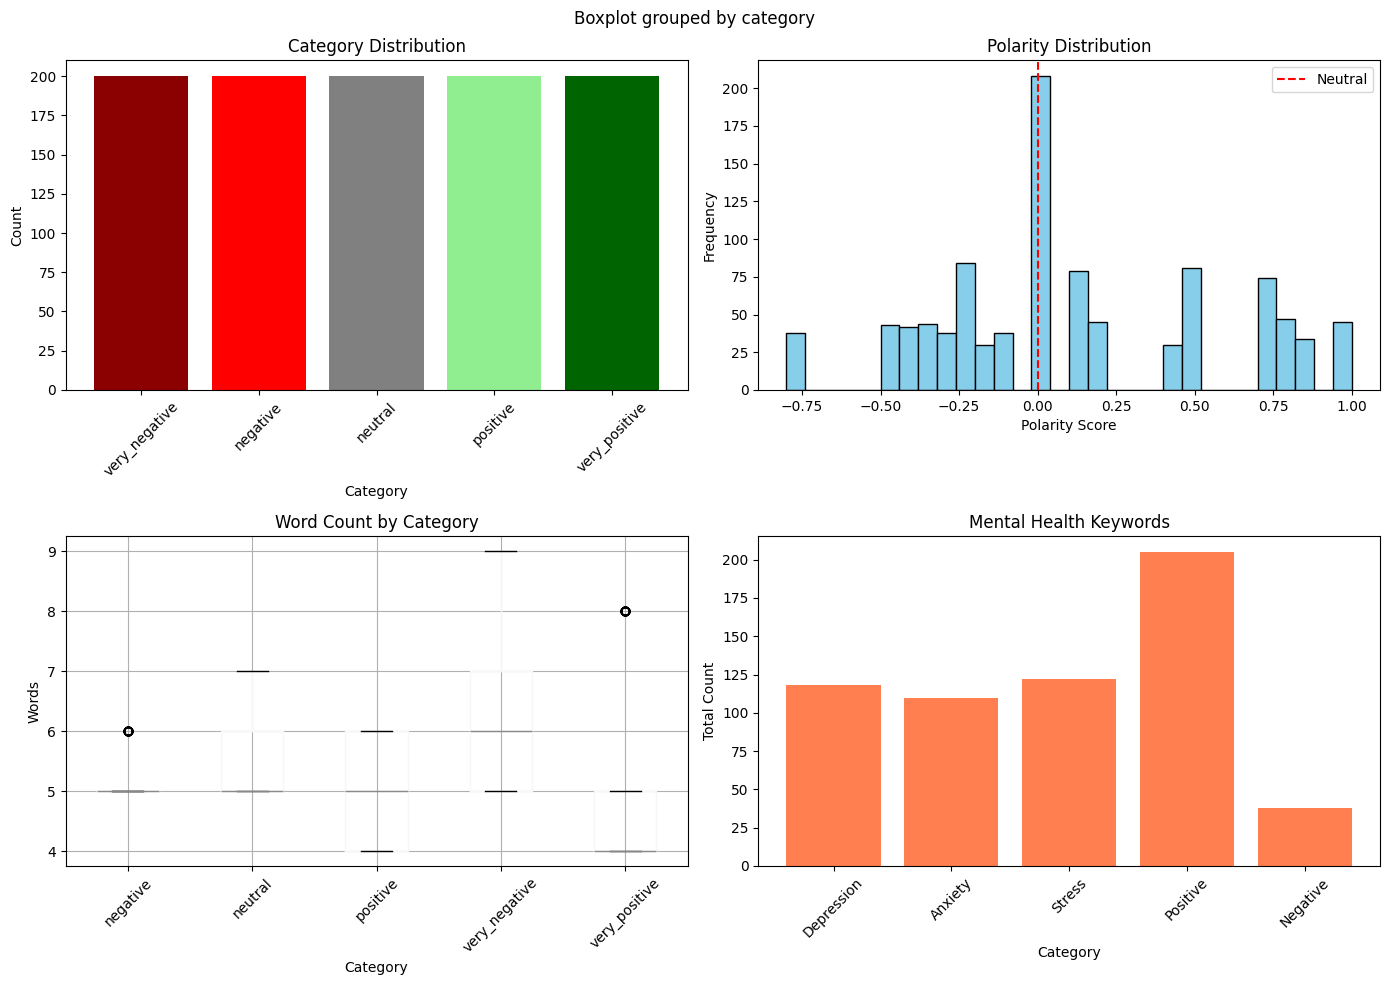


Stats:
        word_count  textblob_polarity
count  1000.000000        1000.000000
mean      5.472000           0.114490
std       1.266815           0.466206
min       4.000000          -0.800000
25%       5.000000          -0.250000
50%       5.000000           0.000000
75%       6.000000           0.500000
max       9.000000           1.000000


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Category distribution
category_counts = df_synthetic['category'].value_counts()
colors = ['darkred', 'red', 'gray', 'lightgreen', 'darkgreen']
axes[0, 0].bar(category_counts.index, category_counts.values, color=colors)
axes[0, 0].set_title('Category Distribution')
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Polarity distribution
axes[0, 1].hist(df_synthetic['textblob_polarity'], bins=30, color='skyblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', label='Neutral')
axes[0, 1].set_title('Polarity Distribution')
axes[0, 1].set_xlabel('Polarity Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Word count by category
df_synthetic.boxplot(column='word_count', by='category', ax=axes[1, 0])
axes[1, 0].set_title('Word Count by Category')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Words')
plt.sca(axes[1, 0])
plt.xticks(rotation=45)

# Mental health keywords
mh_cols = ['mh_depression', 'mh_anxiety', 'mh_stress', 'mh_positive', 'mh_negative']
mh_sums = df_synthetic[mh_cols].sum()
mh_labels = ['Depression', 'Anxiety', 'Stress', 'Positive', 'Negative']
axes[1, 1].bar(mh_labels, mh_sums.values, color='coral')
axes[1, 1].set_title('Mental Health Keywords')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Total Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nStats:\n{df_synthetic[['word_count', 'textblob_polarity']].describe()}")


### Export data

In [17]:
# Create summary
summary = {
    'processing_timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
    'total_samples': len(synthetic_data),
    'categories': categories,
    'statistics': {
        'category_distribution': df_synthetic['category'].value_counts().to_dict(),
        'avg_polarity': float(df_synthetic['textblob_polarity'].mean()),
        'avg_word_count': float(df_synthetic['word_count'].mean())
    }
}

# Save metadata
metadata_file = METADATA_FILE / "text_metadata.json"
with open(metadata_file, 'w') as f:
    json.dump({
        'summary': summary,
        'samples': synthetic_data
    }, f, indent=2)

print(f"✅ Metadata: {metadata_file}")

# Save CSV for ML
csv_file = METADATA_FILE / "text_features_summary.csv"
df_synthetic.to_csv(csv_file, index=False)

print(f"✅ Features CSV: {csv_file}")
print(f"   Shape: {df_synthetic.shape}")
print(f"\n📊 Summary:")
print(f"   Total: {summary['total_samples']}")
print(f"   Categories: {summary['statistics']['category_distribution']}")


✅ Metadata: multimodal_text_data/metadata/text_metadata.json
✅ Features CSV: multimodal_text_data/metadata/text_features_summary.csv
   Shape: (1000, 15)

📊 Summary:
   Total: 1000
   Categories: {'very_negative': 200, 'negative': 200, 'neutral': 200, 'positive': 200, 'very_positive': 200}
